In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import os

# data = pd.read_csv('industry/raw/Communication Services.csv')
# data = pd.read_csv('dataset/USStock/news/AAPL.csv')

stock_list = os.listdir('dataset/USStock/news/')
doc_df = pd.DataFrame()
for stock in stock_list:
    docs = pd.read_csv('dataset/USStock/news/'+stock)['news']
    doc_df = pd.concat([doc_df, docs])
doc_df = doc_df.dropna()
# docs = [str(i) for i in doc_df]


# 将词列表转换为文档-词矩阵
vectorizer = CountVectorizer()
# X = vectorizer.fit_transform(data['news'])
X = vectorizer.fit_transform(doc_df.iloc[:,0])


n_topics = 30  
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)

# 输出每个主题的关键词
def print_top_words(model, feature_names, n_top_words=20):
    for topic_idx, topic in enumerate(model.components_):
        print(f"主题 {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out())

主题 0:
ceo funds roundup chief board buys on hedge to of former schwab as executive pharma inc names freeport vale fund
主题 1:
covid 19 vaccine pfizer for in of fda drug activity coronavirus option to update gets study bhp moderna lilly johnson
主题 2:
the and stocks of for high other with tech to best this are on hold week is yield etfs in
主题 3:
is why it stock than more electric the apos says not but tesla general still in to its today just
主题 4:
stocks us wall street on as higher markets lower ahead of trade earnings after tech to fed st in close
主题 5:
to apos in new for of amazon on and at service ups ceo the workers we jpmorgan office million launches
主题 6:
for news comcast stock disney market top trades to bid fox 2020 rio 2019 billion company unit sky 2018 assets
主题 7:
apple to google in iphone new on for and mobile tech amazon with app antitrust big sprint over at merger
主题 8:
energy to boeing for in max health of 737 and care gas bp air with duke new update oil power
主题 9:
dow as 

In [ ]:
# “公司、股票和能源行业动态”
# 2、《投资、基金与市场分析》
# 3、“疫苗、股票和金融市场最新动态”
# 4、高管变动和股市反应
# 5、股市趋势和投资策略
# 6、《股票购买、经济增长与回报》
# 7、企业新闻和股票市场动向
# 8，“制药、监管和市场动态”
# 9、科技行业及市场发展
# 10、消费者需求和股市影响
# 11、“电子商务、数据和股票市场反应”
# 12、市场表现和收益报告
# 13、《兼并、收购与投资趋势》
# 14、市场波动和股票市场动态
# 15、制药公司和行业趋势
# 16、市场趋势和科技股表现
# 17、投资策略与行业发展
# 18、市场波动和公司动态
# 19、全球市场和经济政策趋势
# 20、股票市场与经济周期
# Topic,Title
# 1,"Energy Sector Dynamics"
# 2,"Investment and Funds"
# 3,"Vaccine"
# 4,Executive Changes
# 5,Investment Strategies
# 6,Economic Growth
# 7,Corporate News
# 8,Pharmaceutical and Regulatory
# 9,Tech Industry
# 10,Consumer Demand
# 11,E-Commerce and Data
# 12,Earnings Reports
# 13,Mergers and Acquisitions
# 14,Market Fluctuations
# 15,Pharmaceutical Companies
# 16,Tech Stocks Performance
# 17,Industry Developments
# 18,Company Dynamics
# 19,Economic Policy Trends
# 20,Economic Cycles


In [7]:
def get_top_words(model, feature_names, n_top_words=20):
    top_words = []
    for topic_idx, topic in enumerate(model.components_):
        topic_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        top_words.append(topic_words)
    return top_words

# 获取关键词
top_words = get_top_words(lda, vectorizer.get_feature_names_out())

# 将每个主题的关键词保存为 CSV 格式
top_words_df = pd.DataFrame(top_words).transpose()

# 将列名设置为 主题 0, 主题 1, ..., 主题 n
top_words_df.columns = [f"topic{i+1}" for i in range(n_topics)]

# 保存为 CSV 文件
top_words_df.to_csv('lda_topic.csv', index=False, header=True)

In [25]:
# 20个主题分别代表什么
# 每支股票每个主题分别bull和bear为多少
import pandas as pd

# 读取topic_table和每个股票的triscales数据
topic_table = pd.read_csv('lda_topic.csv')
topic_columns = topic_table.columns

# total_topic = pd.DataFrame(columns=['name', 'topic', 'bull', 'bear'])
total_topic = []
stock_list = os.listdir('triscores/scale/')
stock_list = [i[:-4] for i in stock_list]

for name in stock_list:
    # 读取每只股票的triscales数据
    data = pd.read_csv(f'triscores/scale/{name}.csv')  # 假设数据包含三列 words, bull, bear
    data = data.dropna()  # 如果有缺失值，可以先去掉缺失值
    
    # 遍历20个主题
    for i in range(20):  # 遍历20个主题
        topic_words = topic_table[topic_columns[i]].dropna().tolist()  # 获取当前主题的所有单词
        
        # 筛选出包含主题单词的 rows
        filtered_data = data[data['words'].isin(topic_words)]
        
        # 计算当前主题的bull和bear值（可以选择总和、均值等）
        bull_values = filtered_data['bull_scores'].mean()  # 或者选择mean()等其他聚合方式
        bear_values = filtered_data['bear_scores'].mean()  # 或者选择mean()等其他聚合方式
        
        # 将每个主题的结果加入到total_topic DataFrame
        topic_row = {
            'name': name,
            'topic': f'{i+1}',
            'bull': bull_values,
            'bear': bear_values
        }
        total_topic.append(topic_row)
        
total_topic = pd.DataFrame(total_topic)
# 保存最终结果
total_topic.to_csv('total_topic_perspective.csv', index=False)

In [26]:
industry_df = pd.read_csv('stock_industry.csv').rename(columns={'Ticker':'name'})

merged_df = pd.merge(total_topic, industry_df, on='name', how='left')

# 保存合并后的结果到新的 CSV 文件
merged_df.to_csv('topic_industry.csv', index=False)

TypeError: 'value' must be an instance of str or bytes, not a float

<Figure size 720x576 with 0 Axes>

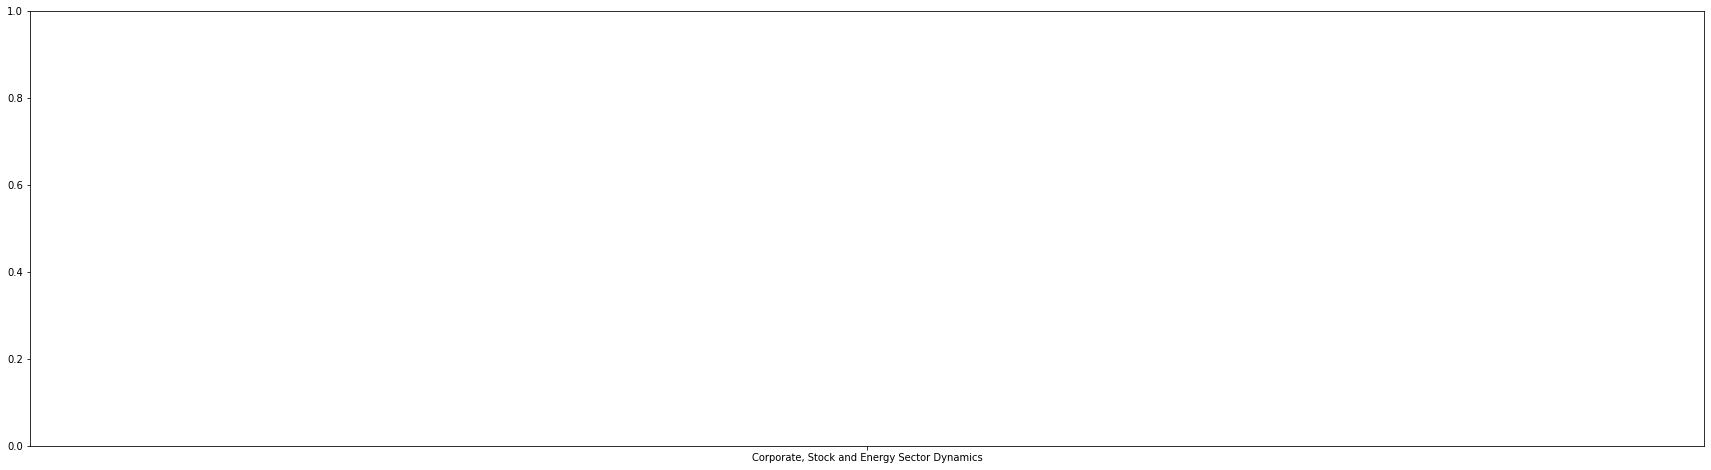

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取包含行业信息的总数据
data = pd.read_csv('topic_industry.csv')
title = pd.read_csv('lda_topic_titles.csv').rename(columns={'Topic':'topic','Title':'title'})
data = pd.merge(data, title, on='topic', how='left')

# 清理列名中的空格
data.columns = data.columns.str.strip()

# 创建两个新的列，分别表示bull和bear泡泡的大小
data['bull_size'] = data['bull']-min(data['bull']) * 2500  # 乘以一个系数来增大泡泡的大小
data['bear_size'] = data['bear']-min(data['bear']) * 25  # 同上，确保泡泡大小足够大

# 创建两个新的列，分别表示bull和bear泡泡的颜色
data['bull_color'] = 'green'  # bull的颜色为绿色
data['bear_color'] = 'red'    # bear的颜色为红色

# 使用 seaborn 绘制泡泡图
plt.figure(figsize=(10, 8))
# sns.scatterplot(x='title', y='Industry', size='bull_size', hue='bull_color', data=data, 
#                 sizes=(600, 600), palette={'green': 'green'}, legend=False, alpha=0.1)

# # 绘制bear的泡泡（红色），确保透明度和bull的泡泡重叠
# sns.scatterplot(x='title', y='Industry', size='bear_size', hue='bear_color', data=data, 
#                 sizes=(600, 600), palette={'red': 'red'}, legend=False, alpha=0.1)
fig, ax1 = plt.subplots(figsize=(30, 8))
ax1.scatter(data['title'], data['Industry'], color='red', s=data['bear_size'] , alpha=0.3, label='Bear') #* 100000
ax1.scatter(data['title'], data['Industry'], color='green', s=data['bull_size'] ,  alpha=0.3, label='Bull') #* 100000

# 设置图表标题和标签
plt.title('Bubble Chart of Topics vs Industry (Bull and Bear)', fontsize=16)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.xticks(rotation=40,fontsize=8)
# 显示图表
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取包含行业信息的总数据
data = pd.read_csv('topic_industry.csv')
title = pd.read_csv('lda_topic_titles.csv').rename(columns={'Topic':'topic','Title':'title'})

# 合并数据，确保行业和主题的对应
data = pd.merge(data, title, on='topic', how='left')

# 清理列名中的空格
data.columns = data.columns.str.strip()

# 检查并处理缺失或无效数据
data['title'] = data['title'].astype(str)  # 确保'title'是字符串类型
data['Industry'] = data['Industry'].astype(str)  # 确保'Industry'是字符串类型

# 创建两个新的列，分别表示bull和bear泡泡的大小
data['bull_size'] = (data['bull'] - min(data['bull'])) * 2500  # 调整大小
data['bear_size'] = (data['bear'] - min(data['bear'])) * 2500  # 调整大小

# 创建两个新的列，分别表示bull和bear泡泡的颜色
data['bull_color'] = 'green'  # bull的颜色为绿色
data['bear_color'] = 'red'    # bear的颜色为红色

# 使用 matplotlib 绘制泡泡图
fig, ax1 = plt.subplots(figsize=(20, 8))

# 绘制bear的泡泡（红色）
ax1.scatter(data['title'], data['Industry'], color='red', s=data['bear_size'], alpha=0.2, label='Bear')

# 绘制bull的泡泡（绿色）
ax1.scatter(data['title'], data['Industry'], color='green', s=data['bull_size'], alpha=0.2, label='Bull')

# 设置图表标题和标签
plt.title('Bubble Chart of Topics vs Industry (Bull and Bear)', fontsize=16)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.xticks(rotation=40, fontsize=8)

# 显示图表
plt.show()


ValueError: Invalid file path or buffer object type: <class 'list'>

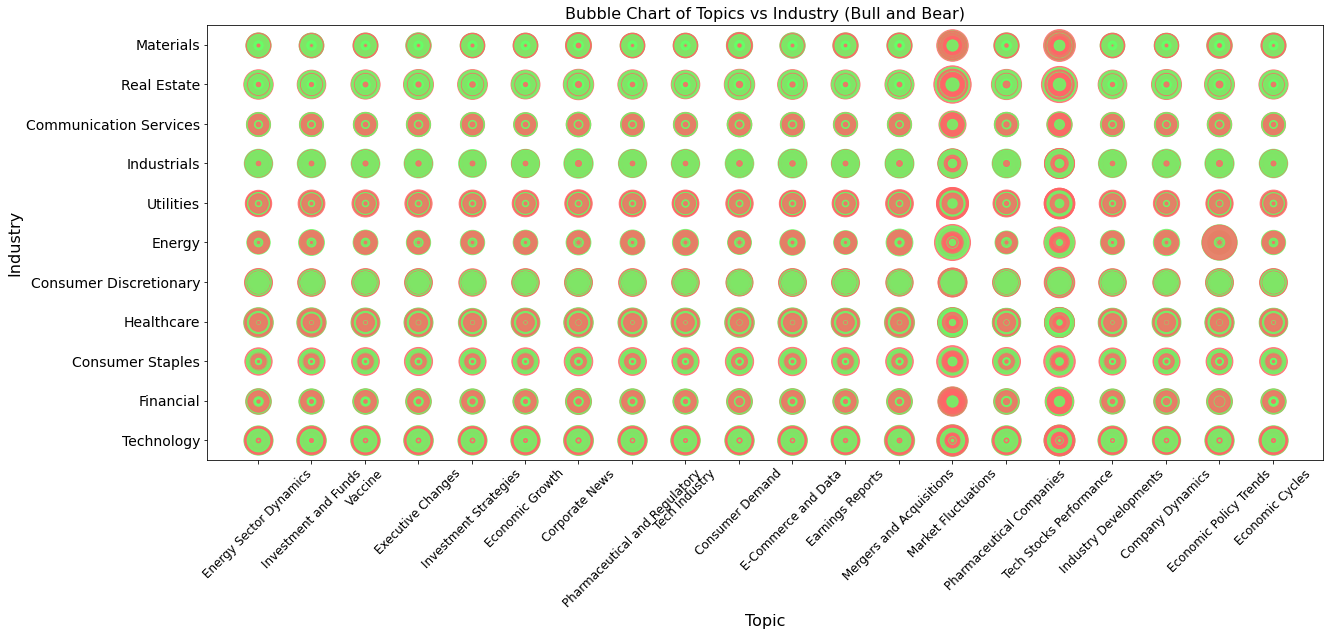

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取包含行业信息的总数据
data = pd.read_csv('topic_industry.csv')
title = pd.read_csv('lda_topic_titles.csv').rename(columns={'Topic':'topic','Title':'title'})

# 合并数据，确保行业和主题的对应
data = pd.merge(data, title, on='topic', how='left')

data = data.dropna()
data.columns = data.columns.str.strip()

# 检查并处理缺失或无效数据
data['title'] = data['title'].astype(str)  # 确保'title'是字符串类型
data['Industry'] = data['Industry'].astype(str)  # 确保'Industry'是字符串类型

# 创建两个新的列，分别表示bull和bear泡泡的大小
data['bull_size'] = (data['bull'] - min(data['bull'])) * 2500  # 调整大小
data['bear_size'] = (data['bear'] - min(data['bear'])) * 2500  # 调整大小

# 创建两个新的列，分别表示bull和bear泡泡的颜色
data['bull_color'] = 'green'  # bull的颜色为绿色
data['bear_color'] = 'red'    # bear的颜色为红色
bull_color = '#66FF66'  # 淡绿色'#CCFFCC'
bear_color = '#FF6666'   # 淡红色'#FFCCCC'
# 使用 matplotlib 绘制泡泡图
fig, ax1 = plt.subplots(figsize=(20, 8))

# 首先绘制较小的泡泡（根据大小判断）
for idx, row in data.iterrows():
    if row['bull_size'] > row['bear_size']:
        # bull_size较大时，绘制bull泡泡在前
        ax1.scatter(row['title'], row['Industry'], color=bull_color, s=row['bull_size'], alpha=0.8, label='Bull' )#if idx == 0 else ""
        ax1.scatter(row['title'], row['Industry'], color=bear_color, s=row['bear_size'], alpha=0.8, label='Bear' )#if idx == 0 else ""
    else:
        # bear_size较大时，绘制bear泡泡在前
        ax1.scatter(row['title'], row['Industry'], color=bear_color, s=row['bear_size'], alpha=0.8, label='Bear' if idx == 0 else "")
        ax1.scatter(row['title'], row['Industry'], color=bull_color, s=row['bull_size'], alpha=0.8, label='Bull' if idx == 0 else "")

plt.title('Bubble Chart of Topics vs Industry (Bull and Bear)', fontsize=16)
plt.xlabel('Topic', fontsize=16)
plt.ylabel('Industry', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=14)
plt.savefig('bubble_topic.pdf')
plt.savefig('bubble_topic.png', dpi=300, bbox_inches='tight') 
plt.show()

金融市场中看涨（Bull）和看跌（Bear）投资者的行为不仅反映了对整体市场的乐观或悲观预期，还揭示了不同行业和主题的关注焦点和风险偏好的差异。我们使用气泡图作为这些差异的直观表示，分析跨行业和主题的多头和空头的分布特征，以发现潜在的市场见解。
新能源、人工智能、金融科技等热点话题主要以较大的看涨泡沫为代表。这表明投资者对这些领域充满信心和关注，反映出市场对其长期增长潜力的乐观态度。

与市场风险或经济衰退相关的话题，例如宏观经济波动或债务问题，主要是看跌泡沫。这种模式凸显了市场在不确定时期规避风险的偏好。

部分话题呈现多空泡沫平衡，表明市场尚未形成明确共识。例如，与产业转型相关的主题（例如能源和技术的交叉）可能会表现出这种平衡分布，表明投资者正在采取观望态度。

\subsubsection{看涨和看跌对比强烈的区域}
从气泡图中，某些行业和主题脱颖而出，看涨和看跌注意力之间形成鲜明对比：

人工智能和区块链等科技领域的主题具有明显更大的看涨泡沫，表明投资者对其增长潜力充满信心。
可再生能源等新兴产业也表现出类似的看涨主导地位，反映出政策支持和技术进步。
看跌主导：

化石燃料等传统能源相关主题显示出明显更大的看跌泡沫，反映出市场对其在全球能源转型中的未来前景的担忧。
房地产等与周期性经济风险相关的话题也表现出看跌主导地位，表明这些领域存在下行压力。
5. 市场差异和潜在机会
气泡图还突出显示了市场存在显着差异的区域：

在看涨和看跌泡沫大小相似的地区，投资者对未来趋势存在很大分歧。
投资影响：这些分歧领域为进一步研究或情景分析提供了机会，以发现潜在的投资机会，特别是在市场达成共识之前。

In [58]:
import pandas as pd

# 主题名称（英文）
topics = [
    "Corporate, Stock and Energy Sector Dynamics",
    "Investment, Funds and Market Analysis",
    "Vaccine, Stocks and Financial Market Updates",
    "Executive Changes and Stock Market Reactions",
    "Stock Market Trends and Investment Strategies",
    "Stock Purchases, Economic Growth and Returns",
    "Corporate News and Stock Market Movements",
    "Pharmaceutical, Regulatory and Market Dynamics",
    "Tech Industry and Market Developments",
    "Consumer Demand and Stock Market Impact",
    "E-Commerce, Data and Stock Market Reactions",
    "Market Performance and Earnings Reports",
    "Mergers, Acquisitions and Investment Trends",
    "Market Fluctuations and Stock Market Dynamics",
    "Pharmaceutical Companies and Industry Trends",
    "Market Trends and Tech Stocks Performance",
    "Investment Strategies and Industry Developments",
    "Market Volatility and Company Dynamics",
    "Global Markets and Economic Policy Trends",
    "Stock Market and Economic Cycles"
]

# 将每个主题的小标题保存为一个数据框
df = pd.DataFrame({
    "Topic": [f"{i+1}" for i in range(20)],
    "Title": topics
})

# 输出到CSV文件
df.to_csv('lda_topic_titles.csv', index=False)
